
 Logistic Regression Evaluation
              precision    recall  f1-score   support

           0       0.37      0.07      0.11     15194
           1       0.67      0.94      0.78     30785

    accuracy                           0.65     45979
   macro avg       0.52      0.50      0.45     45979
weighted avg       0.57      0.65      0.56     45979

 Accuracy: 0.6535

 Random Forest Evaluation
              precision    recall  f1-score   support

           0       0.71      0.63      0.67     15194
           1       0.83      0.88      0.85     30785

    accuracy                           0.79     45979
   macro avg       0.77      0.75      0.76     45979
weighted avg       0.79      0.79      0.79     45979

 Accuracy: 0.7931

 Gradient Boosting Evaluation
              precision    recall  f1-score   support

           0       0.65      0.21      0.32     15194
           1       0.71      0.94      0.81     30785

    accuracy                           0.70     45979
 

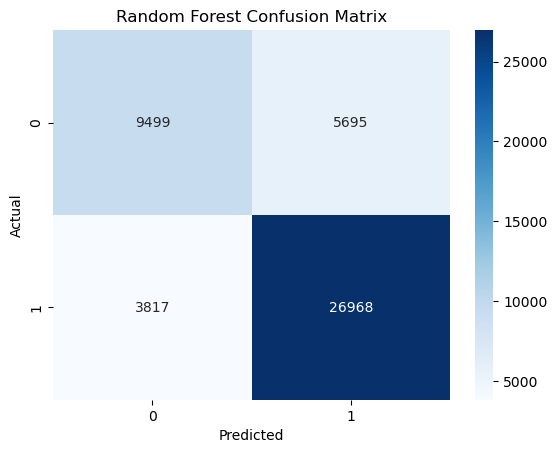

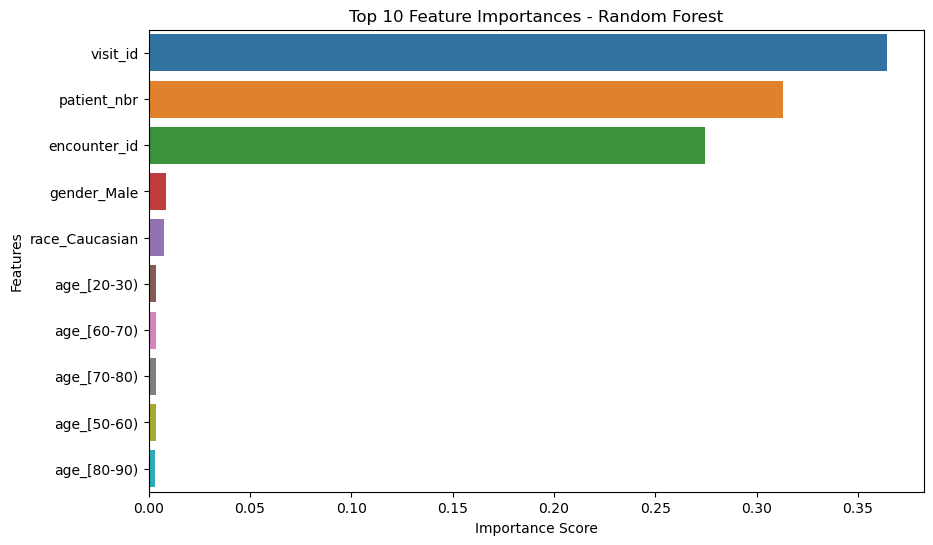

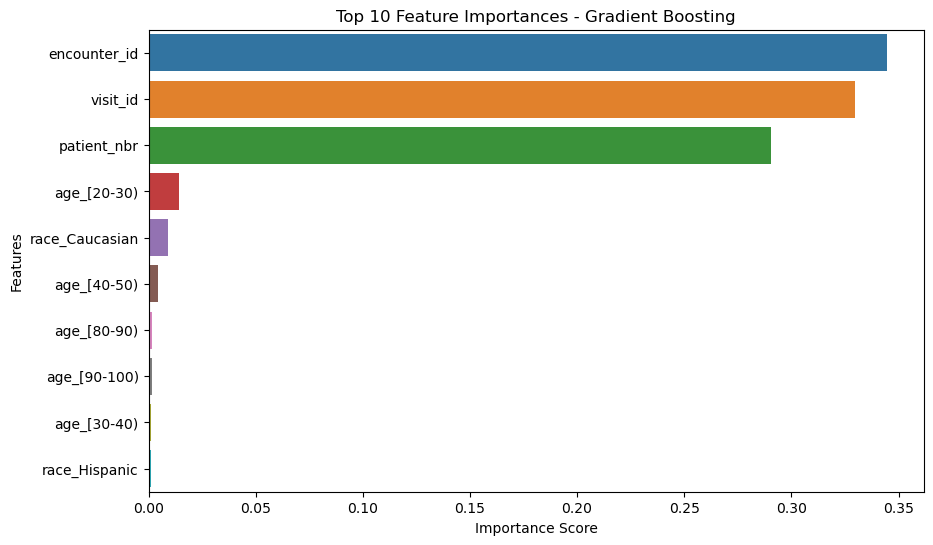

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#  Step 1: Load Processed Dataset
df = pd.read_csv("C:/Users/Durga Vishalini/diabetes-risk-prediction/data/processed_modeling_dataset.csv")

#  Step 2: Define Features (X) and Target (y)
X = df.drop("readmitted", axis=1)
y = df["readmitted"]

#  Step 3: Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#  Step 4: Train Models
log_reg = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)

log_reg.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

#  Step 5: Predictions
models = {"Logistic Regression": log_reg, "Random Forest": rf, "Gradient Boosting": gb}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n {name} Evaluation")
    print(classification_report(y_test, y_pred))
    print(f" Accuracy: {accuracy_score(y_test, y_pred):.4f}")

#  Step 6: Confusion Matrix for Random Forest (as example)
cm = confusion_matrix(y_test, rf.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#  Step 7: Feature Importance for Random Forest
rf_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=rf_importances[:10], y=rf_importances.index[:10])  # Top 10 features
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

#  Step 8: Feature Importance for Gradient Boosting
gb_importances = pd.Series(gb.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=gb_importances[:10], y=gb_importances.index[:10])  # Top 10 features
plt.title("Top 10 Feature Importances - Gradient Boosting")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()


 Random Forest Accuracy: 0.6699580243154484

 Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.01      0.02     15201
           1       0.67      1.00      0.80     30778

    accuracy                           0.67     45979
   macro avg       0.61      0.50      0.41     45979
weighted avg       0.63      0.67      0.54     45979

 Gradient Boosting Accuracy: 0.6696317884251506

 Gradient Boosting Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.00      0.01     15201
           1       0.67      1.00      0.80     30778

    accuracy                           0.67     45979
   macro avg       0.63      0.50      0.40     45979
weighted avg       0.64      0.67      0.54     45979


 Top 10 Features (Random Forest):
age_[20-30)       0.283839
gender_Male       0.126624
race_Caucasian    0.113700
age_[40-50)       0.086640
race_Hispanic     0.058412


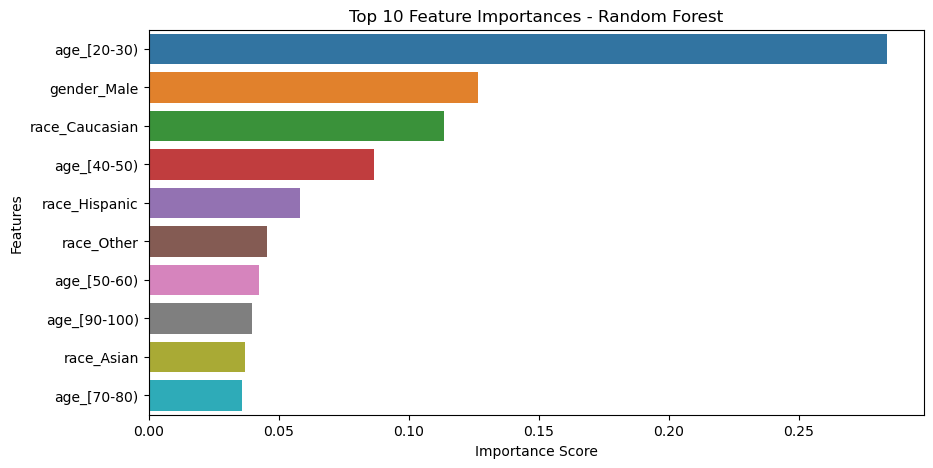

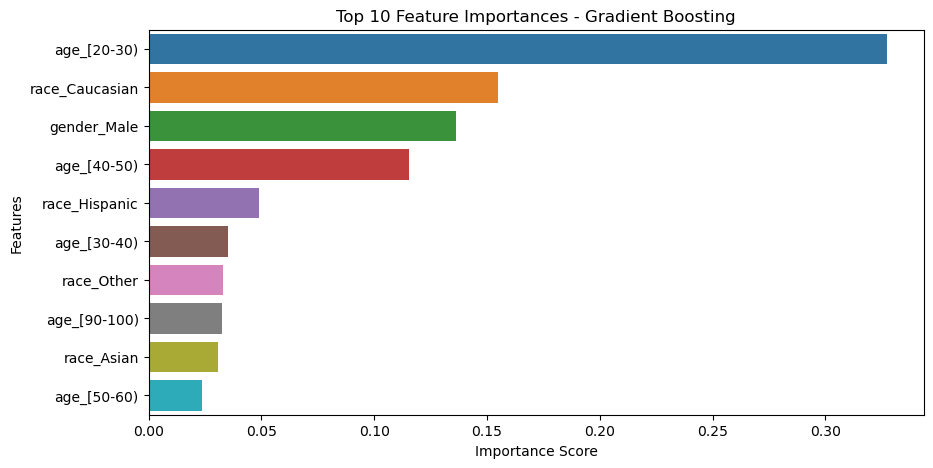

In [2]:

#  Step 1: Drop ID columns (to prevent data leakage)
id_cols = ["visit_id", "patient_nbr", "encounter_id"]
df = df.drop(columns=id_cols)

#  Step 2: Define target and features
X = df.drop(columns=["readmitted"])
y = df["readmitted"]

#  Step 3: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  Step 4: Train Models
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

# Step 5: Evaluate Random Forest
y_pred_rf = rf_model.predict(X_test)
print(" Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\n Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))

# Step 6: Evaluate Gradient Boosting
y_pred_gb = gb_model.predict(X_test)
print(" Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("\n Gradient Boosting Classification Report:\n", classification_report(y_test, y_pred_gb))

# Step 7: Feature Importance - Random Forest
rf_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\n Top 10 Features (Random Forest):")
print(rf_importances.head(10))

#  Step 8: Feature Importance - Gradient Boosting
gb_importances = pd.Series(gb_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\n Top 10 Features (Gradient Boosting):")
print(gb_importances.head(10))

#  Step 9: Plot Feature Importances (Random Forest)
plt.figure(figsize=(10, 5))
sns.barplot(x=rf_importances.head(10).values, y=rf_importances.head(10).index)
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

#  Step 10: Plot Feature Importances (Gradient Boosting)
plt.figure(figsize=(10, 5))
sns.barplot(x=gb_importances.head(10).values, y=gb_importances.head(10).index)
plt.title("Top 10 Feature Importances - Gradient Boosting")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()
